# MDR-TS v7.7
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR
**Notebook Type:** Training & Evaluation  
**Last Updated:** Sun Jan 18th 2026

---

## Model Summary
- **Model Name:** MDR-TS  
- **Version:** v7.7
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/base/split_meta.json`
- **Environment:** Google Colab / VS Code Remote Kernel

---

Adapted for a Macbook M2 Pro environment.



**What's new?**

- Added rain features obtained from analysis (`@see Pipeline/domain_analysis/`)

For other info see `MDR-TS-v1.0`


## 0. Imports

In [17]:
import os
import json
import math
import random
from pathlib import Path

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML / Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
import joblib

# Gradient Boosting (baseline model)
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping

# PyTorch
import torch

# Optuna
import optuna

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"using: {device}")


imports loaded
using: cpu


## 1. Environment Setup

In [4]:
# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

# Environment / Runtime Info
def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    # Colab-specific checks
    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print("  GPU available: False")

print_env_info()

# Plotting defaults
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.10.18
  NumPy version:  1.26.4
  Pandas version: 2.0.3
  XGBoost version: 2.1.2
  Running in Colab: False
  GPU available: False
environment setup complete


## 2. Data Access

In [5]:
# Project paths
VERSION = "v7"
SUBVERSION = "v7.6"
RUN_NAME = "mdr_ts_v7_6"

PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR/"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

# Create output directory if missing
os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))


Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR/
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR//Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR//Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR//Models/Temporal/v7/v7.6

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


## 3. Data Loading

In [6]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_new/train_derived_new.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_new/val_derived_new.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_new/test_derived_new.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

DROP_COLS = ["slope", "elev"]

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    cols_present = [c for c in DROP_COLS if c in d.columns]
    d.drop(columns=cols_present, inplace=True)
    print(f"{name}: dropped columns {cols_present}")
    print(f"\n{name}: shape={d.shape}")
    print(f"{name}: columns={len(d.columns)}")

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_new/train_derived_new.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_new/val_derived_new.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_new/test_derived_new.csv
train: dropped columns ['slope', 'elev']

train: shape=(16972, 352)
train: columns=352
val: dropped columns ['slope', 'elev']

val: shape=(2919, 352)
val: columns=352
test: dropped columns ['slope', 'elev']

test: shape=(2829, 352)
test: columns=352


In [7]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 352

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'aspect', 'DOY', 'soil_moisture_5cm', 'F_NDVI', 'F_NDMI', 'F_MSI', 'E_SAR_ratio', 'E_SAR_diff', 'G_API', 'G_DSLR', 'G_rain_sum_3d', 'G_rain_sum_7d', 'G_rain_sum_30d', 'A_d_G_API_kobs1', 'A_d_G_API_kobs2', 'A_d_G_API_kobs5', 'A_d_G_API_kobs7', 'A_d_G_API_kobs14']


## 4. Data Sanity Checks

In [8]:
# Column definitions (baseline)
TARGET_COL = "soil_moisture_5cm"

KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

FEATURE_COLS = [
  "precip_mm",

  "G_rain_sum_30d",

  "C_lag_E_SAR_diff_kobs12",
  "C_lag_E_SAR_diff_kobs30",
  "C_lag_E_SAR_ratio_kobs30",
  "C_lag_F_NDVI_kobs30",
  "C_lag_LST_modis_kobs12",
  "C_lag_LST_modis_kobs30",
  "DOY",
  "D_sa_E_SAR_ratio",
  "D_sa_F_NDMI",
  "D_z_E_SAR_ratio",
  "D_z_F_NDMI",
  "E_SAR_diff",
  "E_SAR_ratio",
  "F_MSI",
  "F_NDMI",
  "V_ema_LST_modis_kobs30",
  "V_rollmax_E_SAR_diff_kobs14",
  "V_rollmax_E_SAR_diff_kobs30",
  "V_rollmax_F_NDVI_kobs30",
  "V_rollmax_LST_modis_kobs7",
  "V_rollmax_s2_b11_kobs30",
  "V_rollmin_E_SAR_diff_kobs30",
  "V_rollmin_E_SAR_ratio_kobs30",
  "V_rollmin_F_NDMI_kobs30",
  "V_rollmin_s2_b11_kobs30",
  "V_rollmin_s2_b12_kobs30",
  "s1_vh",
  "s2_b8",
  "A_d_LST_modis_kobs7",
  "A_grad_LST_modis_kobs14",
  "C_lag_E_SAR_diff_kobs6",
  "V_rollmax_E_SAR_diff_kobs7",
  "V_rollmax_E_SAR_ratio_kobs14",
  "V_rollmax_F_NDVI_kobs14",
  "s2_b12",
  "D_sa_LST_modis"
]

# quick validation
expected = set(KEEP_META_COLS + FEATURE_COLS + [TARGET_COL])
missing_train = sorted(list(expected - set(train_df.columns)))
missing_val   = sorted(list(expected - set(val_df.columns)))
missing_test  = sorted(list(expected - set(test_df.columns)))

if missing_train or missing_val or missing_test:
    raise ValueError(
        f"Missing columns:\n"
        f"  train: {missing_train}\n"
        f"  val:   {missing_val}\n"
        f"  test:  {missing_test}"
    )

print("Columns locked")
print("  Features:", len(FEATURE_COLS))
print("  Target:  ", TARGET_COL)

Columns locked
  Features: 38
  Target:   soil_moisture_5cm


In [9]:
for d in (train_df, val_df, test_df):
    d["date"] = pd.to_datetime(d["date"], errors="coerce")

stations = sorted(set(train_df["station_id"].dropna().unique())
                  | set(val_df["station_id"].dropna().unique())
                  | set(test_df["station_id"].dropna().unique()))

print("\n=== TEMPORAL LEAKAGE CHECKS (per station) ===")
bad = 0

for sid in stations:
    tr = train_df[train_df["station_id"] == sid]["date"].dropna()
    va = val_df[val_df["station_id"] == sid]["date"].dropna()
    te = test_df[test_df["station_id"] == sid]["date"].dropna()

    if len(tr) == 0 or len(va) == 0 or len(te) == 0:
        print(f"[WARN] station {sid}: missing split data (train={len(tr)}, val={len(va)}, test={len(te)})")
        bad += 1
        continue

    tr_min, tr_max = tr.min(), tr.max()
    va_min, va_max = va.min(), va.max()
    te_min, te_max = te.min(), te.max()

    # date overlap checks (hard leakage)
    overlap_tr_va = len(set(tr.unique()) & set(va.unique()))
    overlap_tr_te = len(set(tr.unique()) & set(te.unique()))
    overlap_va_te = len(set(va.unique()) & set(te.unique()))

    # ordering check (soft but important)
    order_ok = (tr_max < va_min) and (va_max < te_min)

    if overlap_tr_va or overlap_tr_te or overlap_va_te or (not order_ok):
        print(f"[ERROR] station {sid}:")
        print(f"  train: {tr_min} -> {tr_max}")
        print(f"  val:   {va_min} -> {va_max}")
        print(f"  test:  {te_min} -> {te_max}")
        print(f"  overlaps: train∩val={overlap_tr_va}, train∩test={overlap_tr_te}, val∩test={overlap_va_te}")
        print(f"  order_ok: {order_ok}")
        bad += 1
    else:
        print(f"[OK] station {sid}: train<{val_df is not None and 'val' or ''}val<test with no date overlap")

if bad == 0:
    print("\n[INFO] No temporal leakage detected.")
else:
    print(f"\n[WARNING] {bad} station(s) have temporal leakage or split issues.")



=== TEMPORAL LEAKAGE CHECKS (per station) ===
[OK] station Darrington: train<valval<test with no date overlap
[OK] station Quinault: train<valval<test with no date overlap
[OK] station SourdoughGulch_WA_985: train<valval<test with no date overlap
[OK] station Spokane: train<valval<test with no date overlap
[WARN] station Touchet_WA_824: missing split data (train=3311, val=0, test=170)

[WARNING] 1 station(s) have temporal leakage or split issues.


---

### 4.1 Adding the New Features (Experimental)

In [10]:
RAIN_COL = "precip_mm"
RAIN_THR = 4.0     # from my analysis
K = 7              # 0..7 day short horizon
WEIGHTS = np.array([1.0, 0.6, 0.2, 0.1, 0.05, 0.02, 0.01, 0.0], dtype=float)  # len = K+1
NEW_FEATURES = [
    "rain_event_impulse_0_7",
    "rain_mm_impulse_0_7",
    "days_since_rain_event",
]

def add_rain_impulse_features(d: pd.DataFrame) -> pd.DataFrame:
    d = d.copy()
    d["date"] = pd.to_datetime(d["date"], errors="coerce")
    d = d.sort_values(["station_id", "date"]).reset_index(drop=True)

    d["_rain_event"] = (d[RAIN_COL] >= RAIN_THR).astype(int)

    for k in range(0, K + 1):
        d[f"_ev_lag{k}"] = d.groupby("station_id")["_rain_event"].shift(k)
        d[f"_mm_lag{k}"] = d.groupby("station_id")[RAIN_COL].shift(k)

    ev_cols = [f"_ev_lag{k}" for k in range(0, K + 1)]
    mm_cols = [f"_mm_lag{k}" for k in range(0, K + 1)]

    ev_mat = d[ev_cols].fillna(0).to_numpy(dtype=float)
    mm_mat = d[mm_cols].fillna(0).to_numpy(dtype=float)

    d["rain_event_impulse_0_7"] = (ev_mat * WEIGHTS).sum(axis=1)
    d["rain_mm_impulse_0_7"]    = (mm_mat * WEIGHTS).sum(axis=1)

    def _days_since_event(group: pd.DataFrame) -> pd.Series:
        ev = group["_rain_event"].to_numpy()
        out = np.full(len(ev), np.nan, dtype=float)
        last_idx = None
        for i in range(len(ev)):
            if ev[i] == 1:
                last_idx = i
                out[i] = 0.0
            else:
                if last_idx is not None:
                    out[i] = float(i - last_idx)
        return pd.Series(out, index=group.index)

    d["days_since_rain_event"] = (
        d.groupby("station_id", group_keys=False)
         .apply(_days_since_event)
         .clip(upper=30)
    )

    drop_cols = ["_rain_event"] + ev_cols + mm_cols
    d.drop(columns=drop_cols, inplace=True, errors="ignore")

    return d

train_df = add_rain_impulse_features(train_df)
val_df   = add_rain_impulse_features(val_df)
test_df  = add_rain_impulse_features(test_df)

for f in NEW_FEATURES:
    if f not in FEATURE_COLS:
        FEATURE_COLS.append(f)

print("Added new features:", NEW_FEATURES)
print("Total features now:", len(FEATURE_COLS))

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    miss = [c for c in NEW_FEATURES if c not in d.columns]
    if miss:
        raise ValueError(f"{name} missing new features: {miss}")
    print(f"{name}:",
          d[NEW_FEATURES].isna().mean().round(3).to_dict())

Added new features: ['rain_event_impulse_0_7', 'rain_mm_impulse_0_7', 'days_since_rain_event']
Total features now: 41
train: {'rain_event_impulse_0_7': 0.0, 'rain_mm_impulse_0_7': 0.0, 'days_since_rain_event': 0.002}
val: {'rain_event_impulse_0_7': 0.0, 'rain_mm_impulse_0_7': 0.0, 'days_since_rain_event': 0.003}
test: {'rain_event_impulse_0_7': 0.0, 'rain_mm_impulse_0_7': 0.0, 'days_since_rain_event': 0.008}


---

In [11]:
print("\nTemporal split check (train -> validation):")

for sid in sorted(train_df["station_id"].unique()):
    train_dates = train_df.loc[train_df["station_id"] == sid, "date"]
    val_dates   = val_df.loc[val_df["station_id"] == sid, "date"]

    max_train = train_dates.max()
    min_val   = val_dates.min()

    print(f"  Station {sid}:")
    print(f"    train max date: {max_train}")
    print(f"    val   min date: {min_val}")


Temporal split check (train -> validation):
  Station Darrington:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Quinault:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station SourdoughGulch_WA_985:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Spokane:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Touchet_WA_824:
    train max date: 2020-10-28 00:00:00
    val   min date: NaT


## 5. Train / Validation / Test Split

### Split Strategy
- **Training set:**  
  Two stations, early time period  
- **Validation set:**  
  Same stations as training, held-out **future dates** (temporal holdout)
- **Test set:**  
  One completely unseen station (station-level holdout)

### Motivation
- Validation evaluates **temporal generalization** on known stations
- Test evaluates **spatial generalization** to an unseen station
- This avoids spatial leakage while preserving sufficient training data

In [12]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     16972
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2011-10-06 00:00:00 -- 2021-09-23 00:00:00

VAL
  rows:     2919
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2021-09-24 00:00:00 -- 2023-11-12 00:00:00

TEST
  rows:     2829
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2023-11-13 00:00:00 -- 2025-12-31 00:00:00

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']

-- split locked --


## 6. Model Definition

This section defines the MDR-TS v7.6 baseline model.
The emphasis here is **transparency and debuggability**, not maximal performance.

The model is intentionally simple and interpretable:
- Explicit feature matrices
- No feature embedding or deep architecture
- Full access to feature importance and diagnostics

This serves as a reference point for all future MDR models.


### 6.1 Feature Matrix Construction

In [13]:
X_train = train_df[FEATURE_COLS].copy()
y_train = train_df[TARGET_COL].copy()

X_val = val_df[FEATURE_COLS].copy()
y_val = val_df[TARGET_COL].copy()

X_test = test_df[FEATURE_COLS].copy()
y_test = test_df[TARGET_COL].copy()

print("Feature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape}")

Feature matrix shapes:
  X_train: (16972, 41)
  X_val:   (2919, 41)
  X_test:  (2829, 41)
  y_train: (16972,)


### 6.2 Feature Overview

In [14]:
feature_summary = pd.DataFrame({
    "mean": X_train.mean(),
    "std": X_train.std(),
    "min": X_train.min(),
    "max": X_train.max(),
}).sort_values("std", ascending=False)

feature_summary # interactive sheet

,mean,std,min,max
G_rain_sum_30d,1.297717e+02,146.101615,0.000000,1100.500000
DOY,1.856803e+02,102.681888,1.000000,366.000000
rain_mm_impulse_0_7,8.546231e+00,15.033219,0.000000,167.242000
C_lag_LST_modis_kobs12,2.875310e+02,11.630057,248.913937,316.363128
C_lag_LST_modis_kobs30,2.874758e+02,11.628532,248.913937,316.363128
V_rollmax_LST_modis_kobs7,2.887290e+02,11.351500,248.913937,316.363128
V_ema_LST_modis_kobs30,2.875298e+02,10.876158,259.512757,312.940447
precip_mm,4.316409e+00,9.636921,0.000000,127.600000
days_since_rain_event,6.917449e+00,8.871824,0.000000,30.000000
D_sa_LST_modis,-6.162614e-15,5.426353,-23.296544,19.291896


### 6.3 Feature Correlation

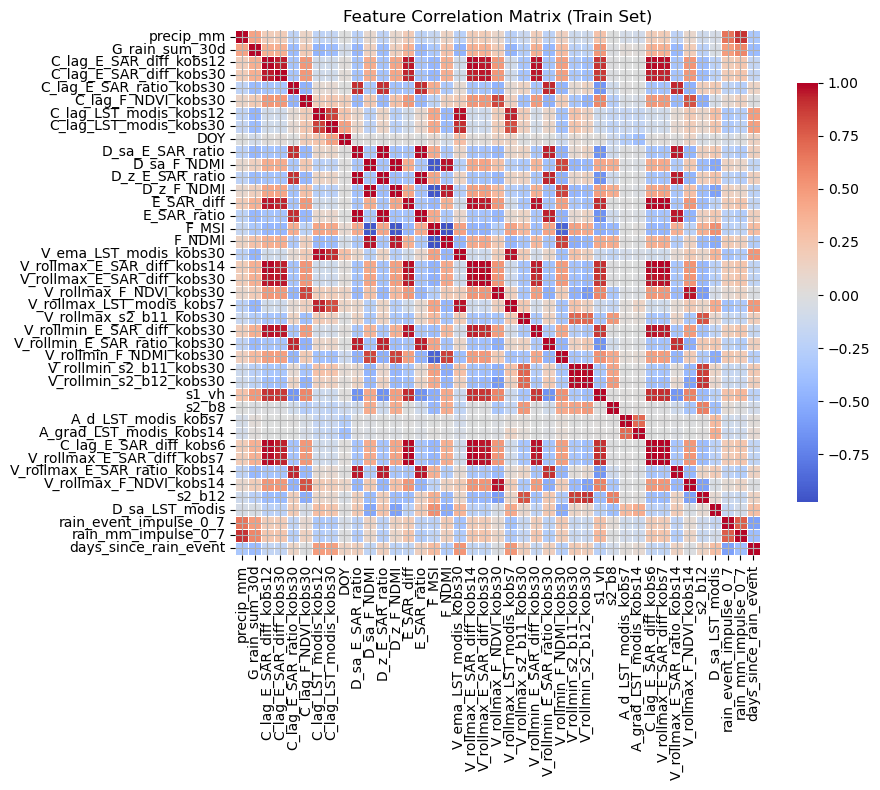

In [15]:
corr = X_train.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Matrix (Train Set)")
plt.tight_layout()
plt.show()

### 6.4 Baseline Model Definition

In [ ]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

N_TRIALS = 60
TIMEOUT_S = None

def objective(trial: optuna.Trial) -> float:
    params = {
        "objective": "reg:squarederror",
        "random_state": SEED,
        "n_jobs": -1,

        # Keep n_estimators moderate since no early stopping
        "n_estimators": trial.suggest_int("n_estimators", 500, 2500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 12),
        "gamma": trial.suggest_float("gamma", 0.0, 2.0),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-6, 0.3, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 8.0, log=True),
    }

    model = XGBRegressor(**params)
    model.fit(X_train, y_train, verbose=False)

    yhat_val = model.predict(X_val)
    return r2_score(y_val, yhat_val)

study = optuna.create_study(direction="maximize", study_name="xgb_r2_tuning_compat")
study.optimize(objective, n_trials=N_TRIALS, timeout=TIMEOUT_S, show_progress_bar=True)

print("\nBest R² (val):", study.best_value)
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

best_params = {
    **study.best_params,
    "objective": "reg:squarederror",
    "random_state": SEED,
    "n_jobs": -1,
}

best_xgb = XGBRegressor(**best_params)
best_xgb.fit(X_train, y_train, verbose=False)

yhat_train = best_xgb.predict(X_train)
yhat_val   = best_xgb.predict(X_val)
yhat_test  = best_xgb.predict(X_test)

print("\nR² scores:")
print("  train:", r2_score(y_train, yhat_train))
print("  val:  ", r2_score(y_val, yhat_val))
print("  test: ", r2_score(y_test, yhat_test))

[I 2026-01-20 21:39:01,579] A new study created in memory with name: xgb_r2_tuning_compat


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2026-01-20 21:39:02,351] Trial 0 finished with value: 0.7047096959824793 and parameters: {'n_estimators': 1777, 'learning_rate': 0.02541630812946819, 'max_depth': 7, 'min_child_weight': 12, 'gamma': 1.6961257914735886, 'subsample': 0.6494993463173949, 'colsample_bytree': 0.883420423639657, 'reg_alpha': 4.813045430508289e-06, 'reg_lambda': 1.4860517417954988}. Best is trial 0 with value: 0.7047096959824793.
[I 2026-01-20 21:39:03,056] Trial 1 finished with value: 0.7800856934630205 and parameters: {'n_estimators': 1674, 'learning_rate': 0.02445370187536168, 'max_depth': 10, 'min_child_weight': 2, 'gamma': 0.33901190480342125, 'subsample': 0.9653131658948966, 'colsample_bytree': 0.5273526105350843, 'reg_alpha': 1.5109742468392581e-05, 'reg_lambda': 1.8186508494658946}. Best is trial 1 with value: 0.7800856934630205.
[I 2026-01-20 21:39:03,670] Trial 2 finished with value: 0.7551794050981189 and parameters: {'n_estimators': 1538, 'learning_rate': 0.035808409608515175, 'max_depth': 8, '

## 7. Training Loop

In [23]:
model_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_jobs=-1,
        random_state=SEED,
        bootstrap=True,

        # best params (from your search)
        n_estimators=800,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features=0.5,
        max_depth=16,
    )),
])

MODEL_CONFIG_RF = {
    "n_estimators": model_rf.named_steps["model"].n_estimators,
    "max_depth": model_rf.named_steps["model"].max_depth,
    "min_samples_leaf": model_rf.named_steps["model"].min_samples_leaf,
    "min_samples_split": model_rf.named_steps["model"].min_samples_split,
    "max_features": model_rf.named_steps["model"].max_features,
    "n_jobs": model_rf.named_steps["model"].n_jobs,
    "random_state": model_rf.named_steps["model"].random_state,
}

print("\nFixed RF params:")
for k, v in MODEL_CONFIG_RF.items():
    print(f"  {k}: {v}")

model_rf.fit(X_train, y_train)

yhat_train_rf = model_rf.predict(X_train)
yhat_val_rf   = model_rf.predict(X_val)
yhat_test_rf  = model_rf.predict(X_test)

print("\nRF predictions generated")
print("  yhat_train_rf:", yhat_train_rf.shape)
print("  yhat_val_rf:  ", yhat_val_rf.shape)
print("  yhat_test_rf: ", yhat_test_rf.shape)


Fixed RF params:
  n_estimators: 800
  max_depth: 16
  min_samples_leaf: 5
  min_samples_split: 10
  max_features: 0.5
  n_jobs: -1
  random_state: 42

RF predictions generated
  yhat_train_rf: (16972,)
  yhat_val_rf:   (2919,)
  yhat_test_rf:  (2829,)


In [25]:
# ---- numpy views (prevents shape/index issues)
yhat_train_np = np.asarray(yhat_train).ravel()
yhat_val_np   = np.asarray(yhat_val).ravel()
yhat_test_np  = np.asarray(yhat_test).ravel()

y_train_np = np.asarray(y_train).ravel()
y_val_np   = np.asarray(y_val).ravel()
y_test_np  = np.asarray(y_test).ravel()

print("Base XGB test R2:", float(r2_score(y_test_np, yhat_test_np)))
print("Base XGB val  R2:", float(r2_score(y_val_np,  yhat_val_np)))
print("Base XGB test bias (true-pred):", float(np.mean(y_test_np - yhat_test_np)))
print()

Base XGB test R2: 0.6843714854169033
Base XGB val  R2: 0.7885692527964197
Base XGB test bias (true-pred): 0.018532432023413443



In [26]:
N_OOF_SPLITS = 5

def build_time_folds(df, n_splits, station_col="station_id", date_col="date"):
    df_sorted = df.sort_values([station_col, date_col]).reset_index(drop=True)
    fold_ids = np.full(len(df_sorted), -1, dtype=int)

    for station, grp in df_sorted.groupby(station_col, sort=False):
        idx = grp.index.to_numpy()
        if len(idx) < n_splits:
            for j, pos in enumerate(idx):
                fold_ids[pos] = j % n_splits
        else:
            splits = np.array_split(idx, n_splits)
            for fold, split_idx in enumerate(splits):
                fold_ids[split_idx] = fold

    if (fold_ids < 0).any():
        raise ValueError("Fold assignment failed")

    return fold_ids


def make_xgb():
    params = model_xgb.get_params()
    params.pop("n_iter", None)
    params["verbosity"] = 0
    return XGBRegressor(**params)


def make_rf():
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_jobs=-1,
            random_state=SEED,
            bootstrap=True,
            n_estimators=MODEL_CONFIG_RF["n_estimators"],
            min_samples_split=MODEL_CONFIG_RF["min_samples_split"],
            min_samples_leaf=MODEL_CONFIG_RF["min_samples_leaf"],
            max_features=MODEL_CONFIG_RF["max_features"],
            max_depth=MODEL_CONFIG_RF["max_depth"],
        )),
    ])


train_df_oof = train_df.reset_index(drop=True)
X_train_oof = X_train.reset_index(drop=True)
y_train_oof = y_train.reset_index(drop=True)

fold_ids = build_time_folds(train_df_oof, n_splits=N_OOF_SPLITS)

oof_xgb = np.zeros(len(X_train_oof))
oof_rf = np.zeros(len(X_train_oof))

for fold in range(N_OOF_SPLITS):
    tr_idx = fold_ids != fold
    va_idx = fold_ids == fold

    X_tr = X_train_oof.loc[tr_idx]
    y_tr = y_train_oof.loc[tr_idx]
    X_va = X_train_oof.loc[va_idx]

    xgb_fold = make_xgb()
    xgb_fold.fit(X_tr, y_tr)
    oof_xgb[va_idx] = xgb_fold.predict(X_va)

    rf_fold = make_rf()
    rf_fold.fit(X_tr, y_tr)
    oof_rf[va_idx] = rf_fold.predict(X_va)

print(f"OOF preds ready: XGB {oof_xgb.shape}, RF {oof_rf.shape}")


OOF preds ready: XGB (16972,), RF (16972,)


In [28]:
def fit_constrained_blender(meta_X, y):
    lr = LinearRegression(positive=True, fit_intercept=False)
    lr.fit(meta_X, y)
    w = np.asarray(lr.coef_).ravel()
    w = np.clip(w, 0, None)
    if w.sum() == 0:
        w = np.ones_like(w) / len(w)
    else:
        w = w / w.sum()
    return w


meta_oof = np.column_stack([oof_xgb, oof_rf])
blend_weights = fit_constrained_blender(meta_oof, y_train_oof.values)

print("Constrained blend weights (sum=1):", blend_weights, "sum=", float(blend_weights.sum()))

yhat_train_blend = blend_weights[0] * oof_xgb + blend_weights[1] * oof_rf
yhat_val_blend = blend_weights[0] * yhat_val_np + blend_weights[1] * np.asarray(yhat_val_rf).ravel()
yhat_test_blend = blend_weights[0] * yhat_test_np + blend_weights[1] * np.asarray(yhat_test_rf).ravel()


Constrained blend weights (sum=1): [0.51754898 0.48245102] sum= 1.0


### 7.2 Metrics

In [29]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def metrics_block(name, y_true, y_pred):
    return {
        "split": name,
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred)),
        "bias_mean(true-pred)": float(np.mean(y_true - y_pred)),
    }


results_before = pd.DataFrame([
    metrics_block("train", y_train_np, yhat_train_np),
    metrics_block("val",   y_val_np,   yhat_val_np),
    metrics_block("test",  y_test_np,  yhat_test_np),
])

results_after = pd.DataFrame([
    metrics_block("train", y_train_oof.values, yhat_train_blend),
    metrics_block("val",   y_val_np,   yhat_val_blend),
    metrics_block("test",  y_test_np,  yhat_test_blend),
])

print("BASELINE (XGB):")
display(results_before)

print("\nAFTER (OOF constrained blend):")

display(results_after)


BASELINE (XGB):


,split,MAE,RMSE,R2,bias_mean(true-pred)
0,train,0.001932,0.002781,0.999260,-0.000002
1,val,0.034954,0.046312,0.788569,0.022262
2,test,0.040642,0.052546,0.684371,0.018532



AFTER (OOF constrained blend):


,split,MAE,RMSE,R2,bias_mean(true-pred)
0,train,0.037239,0.048904,0.771270,0.001009
1,val,0.034289,0.045508,0.795844,0.022901
2,test,0.040088,0.051896,0.692131,0.017917


In [22]:
print("Constrained blend summary:")
print("  weights:", blend_weights)
print("  val R2:", float(r2_score(y_val_np, yhat_val_blend)))
print("  test R2:", float(r2_score(y_test_np, yhat_test_blend)))
print("  test RMSE:", rmse(y_test_np, yhat_test_blend))


Constrained blend summary:
  weights: [0.74242286 0.25757714]
  val R2: 0.8017009915872672
  test R2: 0.7160351195628181
  test RMSE: 0.049840287101399365


### 7.3 Diagnostics

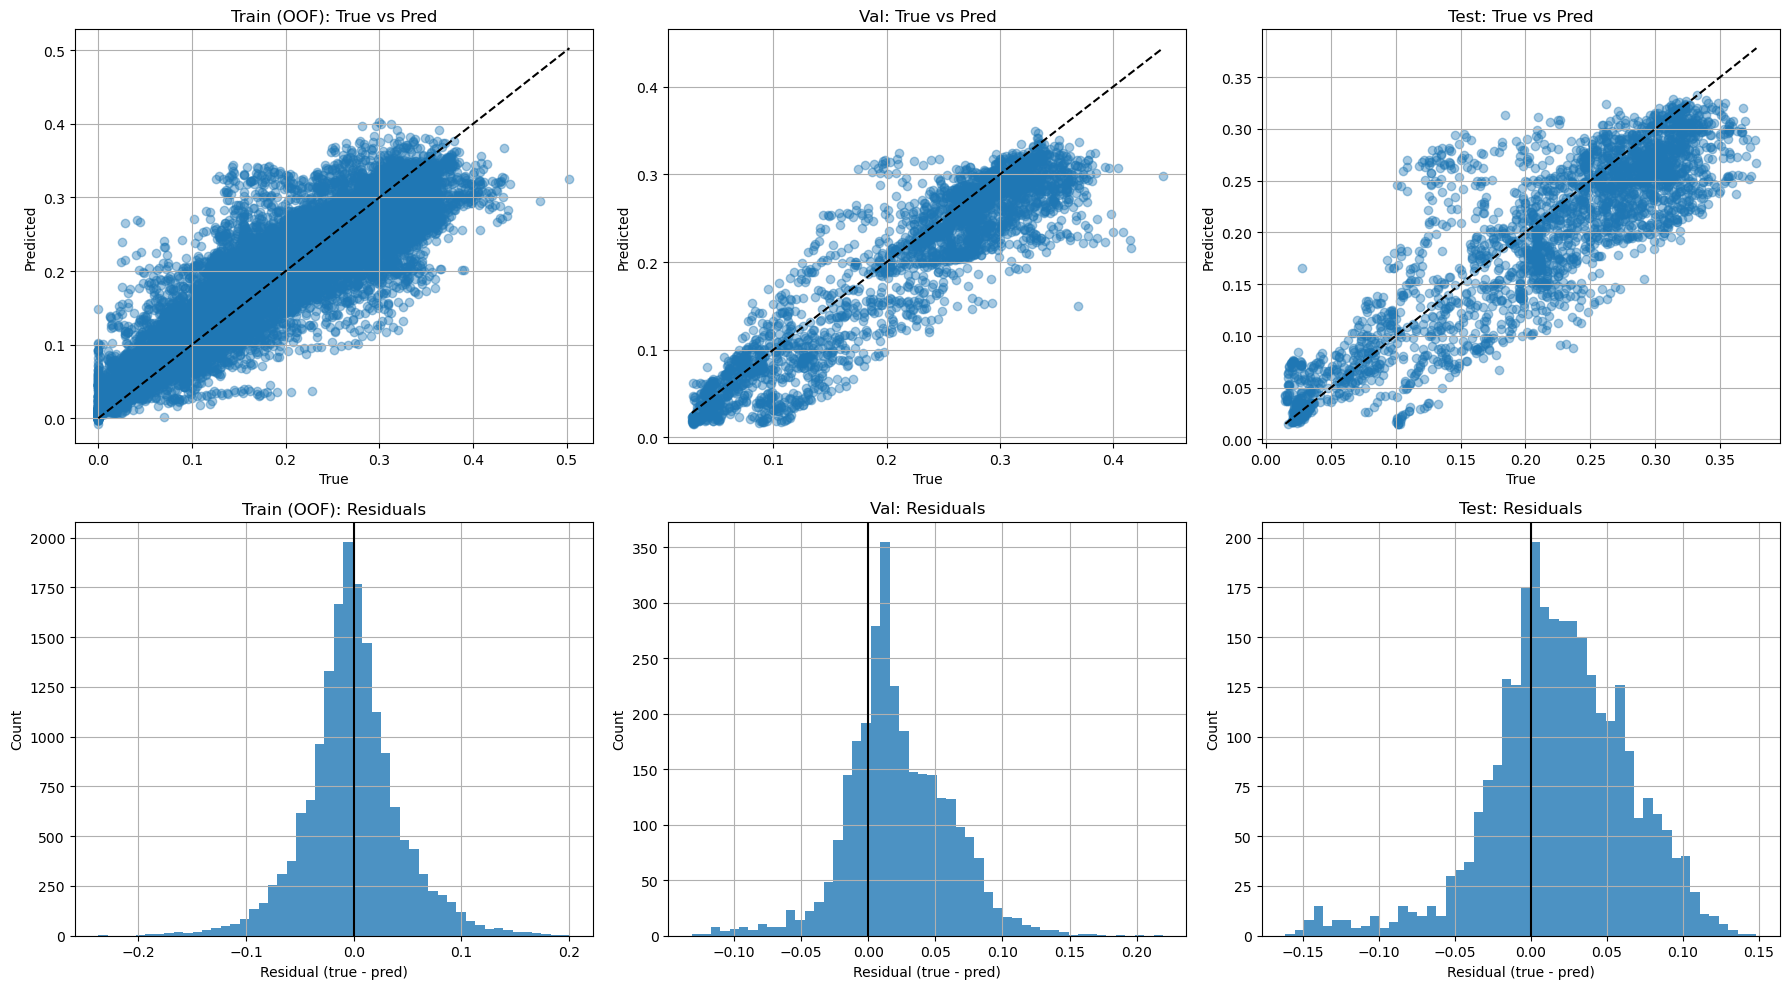

In [24]:
def scatter_plot(ax, y_true, y_pred, title):
    ax.scatter(y_true, y_pred, alpha=0.4)
    ax.plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        color="black",
        linestyle="--",
    )
    ax.set_title(title)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.grid(True)


def residual_hist(ax, y_true, y_pred, title):
    resid = y_true.values - y_pred
    ax.hist(resid, bins=50, alpha=0.8)
    ax.axvline(0, color="black")
    ax.set_title(title)
    ax.set_xlabel("Residual (true - pred)")
    ax.set_ylabel("Count")
    ax.grid(True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

scatter_plot(axes[0, 0], y_train_oof, yhat_train_blend, "Train (OOF): True vs Pred")
scatter_plot(axes[0, 1], y_val,   yhat_val_blend,   "Val: True vs Pred")
scatter_plot(axes[0, 2], y_test,  yhat_test_blend,  "Test: True vs Pred")

residual_hist(axes[1, 0], y_train_oof, yhat_train_blend, "Train (OOF): Residuals")
residual_hist(axes[1, 1], y_val,   yhat_val_blend,   "Val: Residuals")
residual_hist(axes[1, 2], y_test,  yhat_test_blend,  "Test: Residuals")

plt.tight_layout()
plt.show()


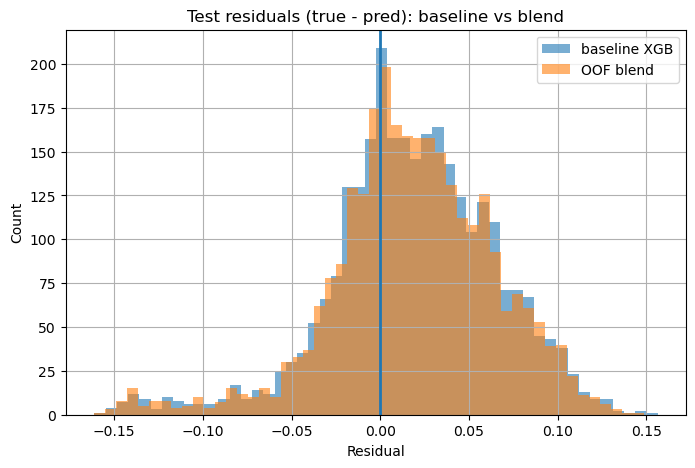

In [25]:
res_before = y_test - yhat_test
res_after  = y_test - yhat_test_blend

plt.figure()
plt.hist(res_before, bins=50, alpha=0.6, label="baseline XGB")
plt.hist(res_after,  bins=50, alpha=0.6, label="OOF blend")
plt.axvline(0, linewidth=2)
plt.title("Test residuals (true - pred): baseline vs blend")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.legend()
plt.show()


### 7.4 Feature Importance

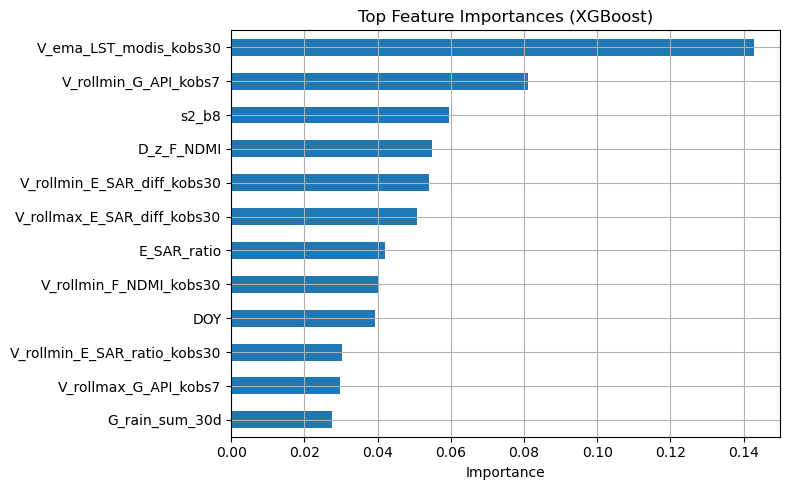

In [26]:
importances_xgb = pd.Series(model_xgb.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances_xgb.head(12).sort_values().plot(kind="barh")
plt.title("Top Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

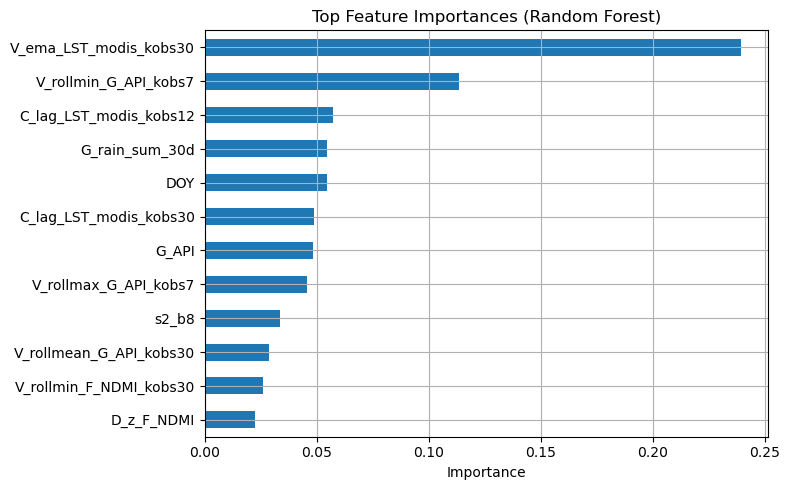

In [27]:
importances_rf = pd.Series(
    model_rf.named_steps["model"].feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances_rf.head(12).sort_values().plot(kind="barh")
plt.title("Top Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [30]:
display(
    pd.DataFrame(
        importances_xgb,
        columns=["importance"]
    ).head(10)
)

,importance
V_ema_LST_modis_kobs30,0.142831
V_rollmin_G_API_kobs7,0.081063
s2_b8,0.059651
D_z_F_NDMI,0.054920
V_rollmin_E_SAR_diff_kobs30,0.054101
V_rollmax_E_SAR_diff_kobs30,0.050698
E_SAR_ratio,0.042125
V_rollmin_F_NDMI_kobs30,0.040062
DOY,0.039238
V_rollmin_E_SAR_ratio_kobs30,0.030242


In [31]:
display(
    pd.DataFrame(
        importances_rf,
        columns=["importance"]
    ).head(10)
)

,importance
V_ema_LST_modis_kobs30,0.239545
V_rollmin_G_API_kobs7,0.113631
C_lag_LST_modis_kobs12,0.057239
G_rain_sum_30d,0.054711
DOY,0.054449
C_lag_LST_modis_kobs30,0.048852
G_API,0.048550
V_rollmax_G_API_kobs7,0.045446
s2_b8,0.033799
V_rollmean_G_API_kobs30,0.028599


## 8. Evaluation

### 8.1 Test Metrics

In [32]:
test_metrics = {
    "MAE":  mean_absolute_error(y_test, yhat_test_blend),
    "RMSE": rmse(y_test, yhat_test_blend),
    "R2":   r2_score(y_test, yhat_test_blend),
    "n":    len(y_test),
}

pd.DataFrame([test_metrics])


,MAE,RMSE,R2,n
0,0.038452,0.04984,0.716035,2829


### 8.2 Test Prediction Scatter

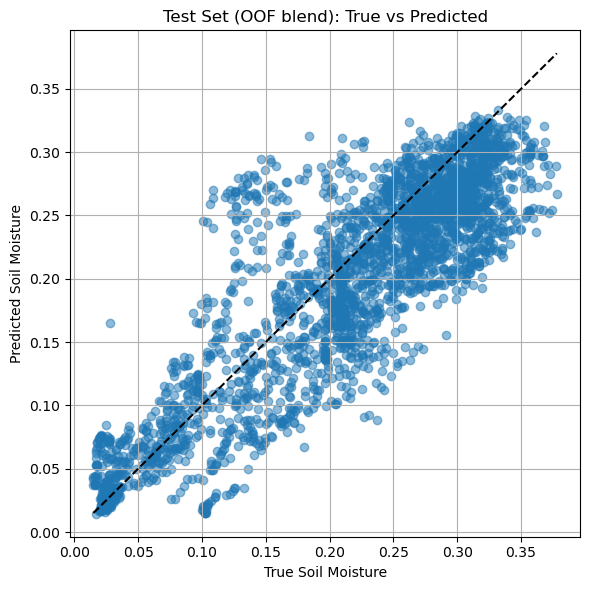

In [33]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, yhat_test_blend, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="black", linestyle="--")
plt.xlabel("True Soil Moisture")
plt.ylabel("Predicted Soil Moisture")
plt.title("Test Set (OOF blend): True vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()


### 8.3 Bias

In [34]:
print(
    "Residual diagnostics\n--------------------\nVAL  residual mean : {val_res:.6f}\nTEST residual mean : {test_res:.6f}\n\nPrediction ranges\n-----------------\nVAL  range : {val_min:.6f} to {val_max:.6f}\nTEST range : {test_min:.6f} to {test_max:.6f}\n"
    .format(
        val_res=float((y_val.values - yhat_val_blend).mean()),
        test_res=float((y_test.values - yhat_test_blend).mean()),
        val_min=float(yhat_val_blend.min()),
        val_max=float(yhat_val_blend.max()),
        test_min=float(yhat_test_blend.min()),
        test_max=float(yhat_test_blend.max()),
    )
)


Residual diagnostics
--------------------
VAL  residual mean : 0.022155
TEST residual mean : 0.018187

Prediction ranges
-----------------
VAL  range : 0.014885 to 0.349437
TEST range : 0.014464 to 0.332969



## 9. Metrics & Visalization

### 9.1 Generalization Gap

In [35]:
results_after = results_after.copy()
results_after.index = ["train", "val", "test"]

gap = {
    "train → val (MAE)": float(results_after.loc["val", "MAE"] - results_after.loc["train", "MAE"]),
    "val → test (MAE)":  float(results_after.loc["test", "MAE"] - results_after.loc["val", "MAE"]),
}

gap_df = pd.DataFrame.from_dict(
    gap,
    orient="index",
    columns=["delta_MAE"]
)

gap_df

,delta_MAE
train → val (MAE),0.001610
val → test (MAE),0.004627


## 10. Save Artifacts

In [36]:
from datetime import datetime

TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

RUN_DIR = os.path.join(OUTPUT_ROOT, f"{RUN_NAME}_{TIMESTAMP}")
os.makedirs(RUN_DIR, exist_ok=True)

print("Run directory:")
print(RUN_DIR)

Run directory:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v7/v7.6/mdr_ts_v7_6_20260118_141451


In [37]:
MODEL_PATH_XGB = os.path.join(RUN_DIR, "model_xgb.json")
model_xgb.save_model(MODEL_PATH_XGB)

MODEL_PATH_RF = os.path.join(RUN_DIR, "model_rf.joblib")
joblib.dump(model_rf, MODEL_PATH_RF)

print("Model saved to:")
print(MODEL_PATH_RF, MODEL_PATH_XGB)


Model saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v7/v7.6/mdr_ts_v7_6_20260118_141451/model_rf.joblib /Users/jbalkovec/Desktop/MDR//Models/Temporal/v7/v7.6/mdr_ts_v7_6_20260118_141451/model_xgb.json


In [38]:
run_metadata = {
    "model_name": "MDR-TS",
    "version": "v7.6",
    "run_name": RUN_NAME,
    "timestamp": TIMESTAMP,
    "model_config_xgb": MODEL_CONFIG_FINAL,
    "model_config_rf": MODEL_CONFIG_RF,
    "blender": {
        "type": "constrained_blend",
        "weights": blend_weights.tolist(),
        "n_splits": N_OOF_SPLITS,
    },
    "features": FEATURE_COLS,
    "target": TARGET_COL,
    "splits": {
        "train_stations": sorted(train_df["station_id"].unique().tolist()),
        "val_stations": sorted(val_df["station_id"].unique().tolist()),
        "test_stations": sorted(test_df["station_id"].unique().tolist()),
    },
    "data_sizes": {
        "train": len(train_df),
        "val": len(val_df),
        "test": len(test_df),
    },
}

META_PATH = os.path.join(RUN_DIR, "run_metadata.json")

with open(META_PATH, "w") as f:
    json.dump(run_metadata, f, indent=2)

print("Run metadata saved to:")
print(META_PATH)


Run metadata saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v7/v7.6/mdr_ts_v7_6_20260118_141451/run_metadata.json


In [39]:
METRICS_PATH = os.path.join(RUN_DIR, "metrics.csv")
results_after.to_csv(METRICS_PATH)

print("Metrics saved to:")
print(METRICS_PATH)

Metrics saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v7/v7.6/mdr_ts_v7_6_20260118_141451/metrics.csv


In [40]:
IMPORTANCE_PATH_XGB = os.path.join(RUN_DIR, "feature_importance_xgb.csv")
importances_xgb.to_csv(IMPORTANCE_PATH_XGB, header=["importance"])

IMPORTANCE_PATH_RF = os.path.join(RUN_DIR, "feature_importance_rf.csv")
importances_xgb.to_csv(IMPORTANCE_PATH_RF, header=["importance"])

print("Feature importance saved to:")
print(IMPORTANCE_PATH_RF, IMPORTANCE_PATH_XGB)

Feature importance saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v7/v7.6/mdr_ts_v7_6_20260118_141451/feature_importance_rf.csv /Users/jbalkovec/Desktop/MDR//Models/Temporal/v7/v7.6/mdr_ts_v7_6_20260118_141451/feature_importance_xgb.csv


In [41]:
# save key figures
FIG_DIR = os.path.join(RUN_DIR, "figures")
# os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(name):
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print("Saved:", path)

---

_Jakob Balkovec_